# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who:** The specific audience I want to communicate with is the Chief Marketing Officer (CMO) or Head of Digital Marketing, who controls the budget allocation for future campaigns and channel investments. This audience is primarily concerned with return on investment, conversion efficiency, and long-term customer retention. If instead addressed parents, product managers, or future customers, the message would change entirely. By focusing on the CMO, I can craft a targeted communication that speaks directly to budget and performance decisions, rather than producing a generic summary that fails to meet any single audience's needs.

**What:** I need the CMO to understand that customer segmentation based on behavioral and channel response patterns significantly improves campaign outcomes. Specifically, I want approval to reallocate a lower percent of the marketing budget away from low performing channels and toward high performing channels. Additionally, I'm requesting authorization to run A/B tests on personalized messaging timing for high value customer segments, with the ultimate goal of increasing both conversion rates and customer lifetime value.

**How:** I will demonstrate success using different datasets to prove that data-driven channel optimization works and justifies the requested budget reallocation.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

**Download Data from Kaggle**


In [2]:
# Install Kaggle library
!pip install kaggle

# Create a .kaggle directory
!mkdir -p ~/.kaggle

# Move the kaggle.json file into the .kaggle directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print('Kaggle API setup complete.')

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API setup complete.


Download the dataset using the Kaggle API.

In [4]:
# Download the dataset
kaggle_dataset_path = 'imakash3011/customer-personality-analysis'
!kaggle datasets download -d {kaggle_dataset_path}

# Unzip the downloaded file
!unzip -o customer-personality-analysis.zip # Added -o option to overwrite if already exists

# Load the CSV file into a pandas DataFrame, specifying the tab delimiter
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Display the first 5 rows of the DataFrame
display(df.head())

Dataset URL: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
License(s): CC0-1.0
customer-personality-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  customer-personality-analysis.zip
  inflating: marketing_campaign.csv  


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**Data Summary and Initial Inspection**

In [5]:
# Display general information about the DataFrame, including data types and non-null values
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2

In [6]:
# Display descriptive statistics for numerical columns
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f'\nNumber of duplicate rows: {duplicate_rows}')

if duplicate_rows > 0:
    print('Dropping duplicate rows.')
    df.drop_duplicates(inplace=True)
    print(f'DataFrame shape after dropping duplicates: {df.shape}')


Number of duplicate rows: 0


**Handling Missing Values and Data Types**

In [8]:
# Fill missing 'Income' values with the median
median_income = df['Income'].median()
df['Income'].fillna(median_income, inplace=True)
print(f"Missing 'Income' values filled with median: {median_income}")

# Convert 'Dt_Customer' to datetime objects
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
print("\n'Dt_Customer' column converted to datetime.")

# Verify that there are no more missing values in 'Income' and check 'Dt_Customer' type
print('\nUpdated DataFrame Info:')
df.info()

Missing 'Income' values filled with median: 51381.5

'Dt_Customer' column converted to datetime.

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240

/tmp/ipykernel_24588/2869164576.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(median_income, inplace=True)


**Addressing Data Inconsistencies and Outliers**

In [9]:
# Calculate current year for age calculation
current_year = datetime.now().year

# Calculate age and identify unusual birth years
df['Age'] = current_year - df['Year_Birth']

# Display rows with 'Age' greater than 100 (assuming maximum reasonable age)
print("\nCustomers with unusually high 'Age' (possibly incorrect 'Year_Birth'):")
display(df[df['Age'] > 100])

# Decision: For now, I will keep these rows, but note them as potential outliers for further investigation.
# If required, we can remove them or impute a more reasonable birth year based on domain knowledge.

# Identify and drop columns with zero variance
zero_variance_cols = [col for col in df.columns if df[col].nunique() == 1]
if zero_variance_cols:
    print(f"\nColumns with zero variance (all values are the same): {zero_variance_cols}")
    df.drop(columns=zero_variance_cols, inplace=True)
    print(f"Dropped columns: {zero_variance_cols}. New DataFrame shape: {df.shape}")
else:
    print("\nNo columns with zero variance found.")

# Display the first few rows of the cleaned DataFrame
print("\nDataFrame head after cleaning:")
display(df.head())


Customers with unusually high 'Age' (possibly incorrect 'Year_Birth'):


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,0,0,0,0,0,1,3,11,0,126
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,0,3,11,0,133
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0,0,1,0,0,0,3,11,0,127



Columns with zero variance (all values are the same): ['Z_CostContact', 'Z_Revenue']
Dropped columns: ['Z_CostContact', 'Z_Revenue']. New DataFrame shape: (2240, 28)

DataFrame head after cleaning:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,0,0,0,0,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,0,0,0,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,0,0,0,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,0,0,0,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,0,0,0,0,0,45


**Further Data Inspection: Uniqueness, Central Tendency, and Remaining Missing Values**

In [10]:
# Check for duplicate values in the 'ID' column
id_duplicates = df['ID'].duplicated().sum()
print(f"Number of duplicate 'ID' values: {id_duplicates}")

if id_duplicates > 0:
    print("Warning: Duplicate 'ID' values found. This might indicate an issue if 'ID' should be unique.")

# Calculate mean, median, and mode for all columns
print("\nMean of each numerical column:")
display(df.select_dtypes(include=np.number).mean())

print("\nMedian of each numerical column:")
display(df.select_dtypes(include=np.number).median())

print("\nMode of each column (top 3 if multiple modes exist):")
for col in df.columns:
    if df[col].dtype == 'object' or df[col].nunique() < 20: # Display mode for categorical or low-cardinality numerical columns
        modes = df[col].mode()
        print(f"  {col}: {modes.tolist()[:3]}")
    elif df[col].dtype == 'int64' or df[col].dtype == 'float64': # For high-cardinality numerical columns, just print the top mode
        modes = df[col].mode()
        if not modes.empty:
            print(f"  {col}: {modes.iloc[0]}")

# Check for any remaining missing values across the DataFrame
print("\nRemaining missing values per column:")
missing_values_after = df.isnull().sum()
print(missing_values_after[missing_values_after > 0])

Number of duplicate 'ID' values: 0

Mean of each numerical column:


,0
ID,5592.159821
Year_Birth,1968.805804
Income,52237.975446
Kidhome,0.444196
Teenhome,0.506250
Recency,49.109375
MntWines,303.935714
MntFruits,26.302232
MntMeatProducts,166.950000
MntFishProducts,37.525446



Median of each numerical column:


,0
ID,5458.5
Year_Birth,1970.0
Income,51381.5
Kidhome,0.0
Teenhome,0.0
Recency,49.0
MntWines,173.5
MntFruits,8.0
MntMeatProducts,67.0
MntFishProducts,12.0



Mode of each column (top 3 if multiple modes exist):
  ID: 0
  Year_Birth: 1976
  Education: ['Graduation']
  Marital_Status: ['Married']
  Income: 51381.5
  Kidhome: [0]
  Teenhome: [0]
  Recency: 56
  MntWines: 2
  MntFruits: 0
  MntMeatProducts: 7
  MntFishProducts: 0
  MntSweetProducts: 0
  MntGoldProds: 1
  NumDealsPurchases: [1]
  NumWebPurchases: [2]
  NumCatalogPurchases: [0]
  NumStorePurchases: [3]
  NumWebVisitsMonth: [7]
  AcceptedCmp3: [0]
  AcceptedCmp4: [0]
  AcceptedCmp5: [0]
  AcceptedCmp1: [0]
  AcceptedCmp2: [0]
  Complain: [0]
  Response: [0]
  Age: 50

Remaining missing values per column:
Series([], dtype: int64)


**Encoding Categorical Variables**

In [11]:
# Identify categorical columns to be encoded
categorical_cols = ['Education', 'Marital_Status']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Original DataFrame shape: {df.shape}")
print(f"Encoded DataFrame shape: {df_encoded.shape}")

print("\nFirst 5 rows of the DataFrame after one-hot encoding:")
display(df_encoded.head())

Original DataFrame shape: (2240, 28)
Encoded DataFrame shape: (2240, 37)

First 5 rows of the DataFrame after one-hot encoding:


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,True,False,False,False,False,False,True,False,False,False
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,True,False,False,False,False,False,True,False,False,False
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,True,False,False,False,False,False,False,True,False,False
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,True,False,False,False,False,False,False,True,False,False
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,False,False,True,False,False,True,False,False,False,False


**Check for Class Imbalance**

In [12]:
# Check class imbalance for the 'Response' column
response_counts = df_encoded['Response'].value_counts()
response_percentages = df_encoded['Response'].value_counts(normalize=True) * 100

print("Class distribution for 'Response' column:")
print(response_counts)
print("\nClass percentages for 'Response' column:")
print(response_percentages)

# Provide a summary/conclusion based on all the steps performed
print("\n--- Data Preparation Summary and Conclusions ---")
print("1. Data Usability: The data are largely usable. Missing values in 'Income' were handled, 'Dt_Customer' was converted, and zero-variance columns were removed. Some 'Year_Birth' outliers exist but were noted.")
print("2. Further Modifications: The 'Year_Birth' outliers (very old ages) might need specific handling (e.g., removal or imputation) depending on the specific analysis or modeling goals. No other immediate, critical modifications are needed beyond what's been done.")
print("3. Class Imbalance: The 'Response' column shows significant class imbalance, with a much smaller percentage of customers responding to the campaign. This will be an important consideration for any predictive modeling.")
print("\nData is now clean and prepared for further analysis or model building. What would you like to explore next?")

Class distribution for 'Response' column:
Response
0    1906
1     334
Name: count, dtype: int64

Class percentages for 'Response' column:
Response
0    85.089286
1    14.910714
Name: proportion, dtype: float64

--- Data Preparation Summary and Conclusions ---
1. Data Usability: The data are largely usable. Missing values in 'Income' were handled, 'Dt_Customer' was converted, and zero-variance columns were removed. Some 'Year_Birth' outliers exist but were noted.
2. Further Modifications: The 'Year_Birth' outliers (very old ages) might need specific handling (e.g., removal or imputation) depending on the specific analysis or modeling goals. No other immediate, critical modifications are needed beyond what's been done.
3. Class Imbalance: The 'Response' column shows significant class imbalance, with a much smaller percentage of customers responding to the campaign. This will be an important consideration for any predictive modeling.

Data is now clean and prepared for further analysis o

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

**Data Visualization: Income Distribution by Campaign Response**

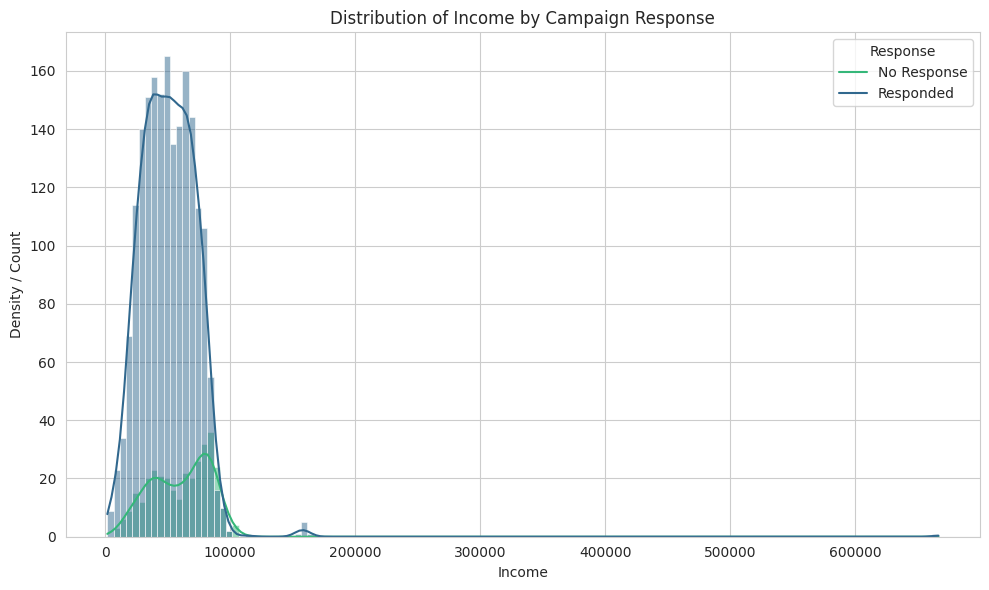

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=df_encoded, x='Income', hue='Response', kde=True, palette='viridis', common_norm=False)
plt.title('Distribution of Income by Campaign Response')
plt.xlabel('Income')
plt.ylabel('Density / Count')
plt.legend(title='Response', labels=['No Response', 'Responded'])
plt.tight_layout()
plt.show()

**Insight 1:** Higher Income and Response Rate From the plot, we can observe that customers with higher incomes tend to have a higher response rate to the campaign. The distribution for 'Responded' (orange curve) is shifted towards higher income levels compared to 'No Response' (blue curve), which peaks at a lower income range.

**Insight 2:** Income Threshold for Engagement There appears to be a noticeable increase in the density of responders as income rises, particularly above approximately $50,000 to $$50,000 to $60,000. This suggests that marketing efforts might be more effective when targeted towards customers within higher income brackets.

This visualization provides a clear insight into a potential demographic factor influencing campaign success, aligning with your objective to understand customer segments for improved campaign outcomes.